### 2.2. Generation dataset
This cleaning process includes:
1. The aggregation of the five files containing TERNA data about generated electricity so that we have the complete time series from 2021 to 2025;
2. The deletetion of rows with NULL values, due to the final message that occupies only 1 or 2 cells on each Excel file, indicating which filter had been applied while manually downloading the data;
3. The assignment of the correct data type to each column;
4. Mtu (Market Time Unit) harmonization, since from October 1st energy market is detailed at 15-min frequency.  

After data cleaning, the new dataset is expected to be copied in the <code>/dataset/clean</code> folder.


In [2]:
# import libraries
import pandas as pd
from pathlib import Path
import warnings

# filter User and Future Warnings for privacy matters
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)

# define initial variables
dataset_path = Path('../dataset/raw')           # input folder path
output_path = Path('../dataset/clean/updated')  # output folder path
output_path.mkdir(parents=True, exist_ok=True)  # create folder if non-existent

YEARS = range(2023, 2027)

In [3]:
# 1. Aggregate generation data in dataframe
gen_dfs = [
    pd.read_excel(dataset_path / f'TERNA-gen-{year}.xlsx')
    for year in YEARS
]
generation_data = pd.concat(gen_dfs, ignore_index=True)

# fast check
print(f'''
----Rows x Cols:----
{generation_data.shape}\n
----First rows:----
{generation_data.head()}\n
----Last rows:----
{generation_data.tail()}
''')


----Rows x Cols:----
(417400, 3)

----First rows:----
                  Date  Actual Generation    Primary Source
0  2023-12-31 23:00:00             12.850           Thermal
1  2023-12-31 23:00:00              2.460             Hydro
2  2023-12-31 23:00:00              0.630        Geothermal
3  2023-12-31 23:00:00              0.000      Photovoltaic
4  2023-12-31 23:00:00              1.446  Self-consumption

----Last rows:----
                                   Date  Actual Generation    Primary Source
417395              2026-01-01 00:00:00              0.000      Photovoltaic
417396              2026-01-01 00:00:00             17.480           Thermal
417397              2026-01-01 00:00:00              1.892  Self-consumption
417398              2026-01-01 00:00:00              2.040             Hydro
417399  Applied filters:  Year is 2026;                NaN               NaN



In [4]:
print(f'''
{generation_data.info()}\n
----Date description----
{generation_data['Date'].describe()}\n
----Actual energy generation description----
{generation_data['Actual Generation'].describe()}\n
----Source of production----
{generation_data['Primary Source'].describe()}\n
''')

<class 'pandas.DataFrame'>
RangeIndex: 417400 entries, 0 to 417399
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date               417400 non-null  object 
 1   Actual Generation  417396 non-null  float64
 2   Primary Source     417396 non-null  str    
dtypes: float64(1), object(1), str(1)
memory usage: 9.6+ MB

None

----Date description----
count                  417400
unique                  69567
top       2023-10-29 02:00:00
freq                       12
Name: Date, dtype: object

----Actual energy generation description----
count    417396.000000
mean          5.030427
std           5.721679
min           0.000000
25%           0.610000
50%           3.080000
75%           6.756000
max          43.600000
Name: Actual Generation, dtype: float64

----Source of production----
count      417396
unique          6
top       Thermal
freq        69566
Name: Primary Source, dtype: object




In [5]:
# 2. Delete n=5 Rows with NULL values it's the row at the end of each dataset (for each year) which explains the applied filter
generation_data = generation_data.dropna(axis=0, how='any')
print(generation_data.head(10) )       # check

# 3. Convert Date from Object type to Datetime type
generation_data['Date'] = pd.to_datetime(generation_data['Date'], dayfirst=True, errors='coerce')
#    Convert Primary Source from Object to String
generation_data['Primary Source'] = generation_data['Primary Source'].astype('string')

generation_data.columns

                  Date  Actual Generation    Primary Source
0  2023-12-31 23:00:00             12.850           Thermal
1  2023-12-31 23:00:00              2.460             Hydro
2  2023-12-31 23:00:00              0.630        Geothermal
3  2023-12-31 23:00:00              0.000      Photovoltaic
4  2023-12-31 23:00:00              1.446  Self-consumption
5  2023-12-31 23:00:00              3.460              Wind
6  2023-12-31 22:00:00              2.720             Hydro
7  2023-12-31 22:00:00              1.597  Self-consumption
8  2023-12-31 22:00:00              0.000      Photovoltaic
9  2023-12-31 22:00:00              0.630        Geothermal


Index(['Date', 'Actual Generation', 'Primary Source'], dtype='str')

In [6]:
# 4. MTU harmonization
generation_data = (
    generation_data
    .groupby(['Primary Source', pd.Grouper(key='Date', freq='h')])
    .mean()
    .reset_index()
)

# pivoted table
generation_pivot = generation_data.pivot(
    index='Date',
    columns='Primary Source',
    values='Actual Generation'
)

It is now useful to add new columns for further data analysis. 
<code>TOT Generation</code> sums the total generated energy that entered in the energy market.  
It sums <code>Geothermal</code>, <code>Hydro</code>, <code>Photovoltaic</code>, <code>Thermal</code>, <code>Wind</code>.  
<code>Self-consumption</code> is excluded by this calculation, since it represents the amount of energy produced, but employed for self consumption and so, hasn't been traded in energy markets.

In [7]:
# calculate total generation 
generation_pivot['TOT Generation'] = generation_pivot[['Geothermal', 'Hydro', 'Photovoltaic', 'Thermal', 'Wind',]].sum(axis=1)
generation_pivot.head()

Primary Source,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation
Date,,,,,,,
2023-01-01 00:00:00,0.62,1.81,0.0,1.443,14.47,0.20,17.10
2023-01-01 01:00:00,0.62,1.66,0.0,1.365,13.85,0.16,16.29
2023-01-01 02:00:00,0.62,1.61,0.0,1.260,12.93,0.16,15.32
2023-01-01 03:00:00,0.62,1.61,0.0,1.191,12.32,0.18,14.73
2023-01-01 04:00:00,0.62,1.56,0.0,1.081,11.99,0.22,14.39


<code>Renewables weight</code> is an index calculated by the total of energy produced by renewables, divided by the total amount of energy generated. In this case <code>Thermal</code> energy is excluded by this list, since it represents the coverage through fossils.

In [8]:
# add renewables weights column
generation_pivot['Renewables weight'] = (
    generation_pivot[['Geothermal', 'Hydro', 'Photovoltaic', 'Wind']].sum(axis=1)
    / generation_pivot['TOT Generation']
)

# export dataset
generation_pivot.to_csv(output_path / 'gen-clean.csv')

# show updated table
generation_pivot

Primary Source,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight
Date,,,,,,,,
2023-01-01 00:00:00,0.62,1.81,0.00,1.443,14.47,0.20,17.10,0.153801
2023-01-01 01:00:00,0.62,1.66,0.00,1.365,13.85,0.16,16.29,0.149785
2023-01-01 02:00:00,0.62,1.61,0.00,1.260,12.93,0.16,15.32,0.156005
2023-01-01 03:00:00,0.62,1.61,0.00,1.191,12.32,0.18,14.73,0.163612
2023-01-01 04:00:00,0.62,1.56,0.00,1.081,11.99,0.22,14.39,0.166782
...,...,...,...,...,...,...,...,...
2026-06-28 19:00:00,0.56,7.50,1.85,3.359,21.10,0.98,31.99,0.340419
2026-06-28 20:00:00,0.56,8.77,0.19,2.801,21.92,0.73,32.17,0.318620
2026-06-28 21:00:00,0.56,8.43,0.00,2.858,22.61,0.58,32.18,0.297390


In [9]:
generation_pivot.columns

Index(['Geothermal', 'Hydro', 'Photovoltaic', 'Self-consumption', 'Thermal',
       'Wind', 'TOT Generation', 'Renewables weight'],
      dtype='string', name='Primary Source')

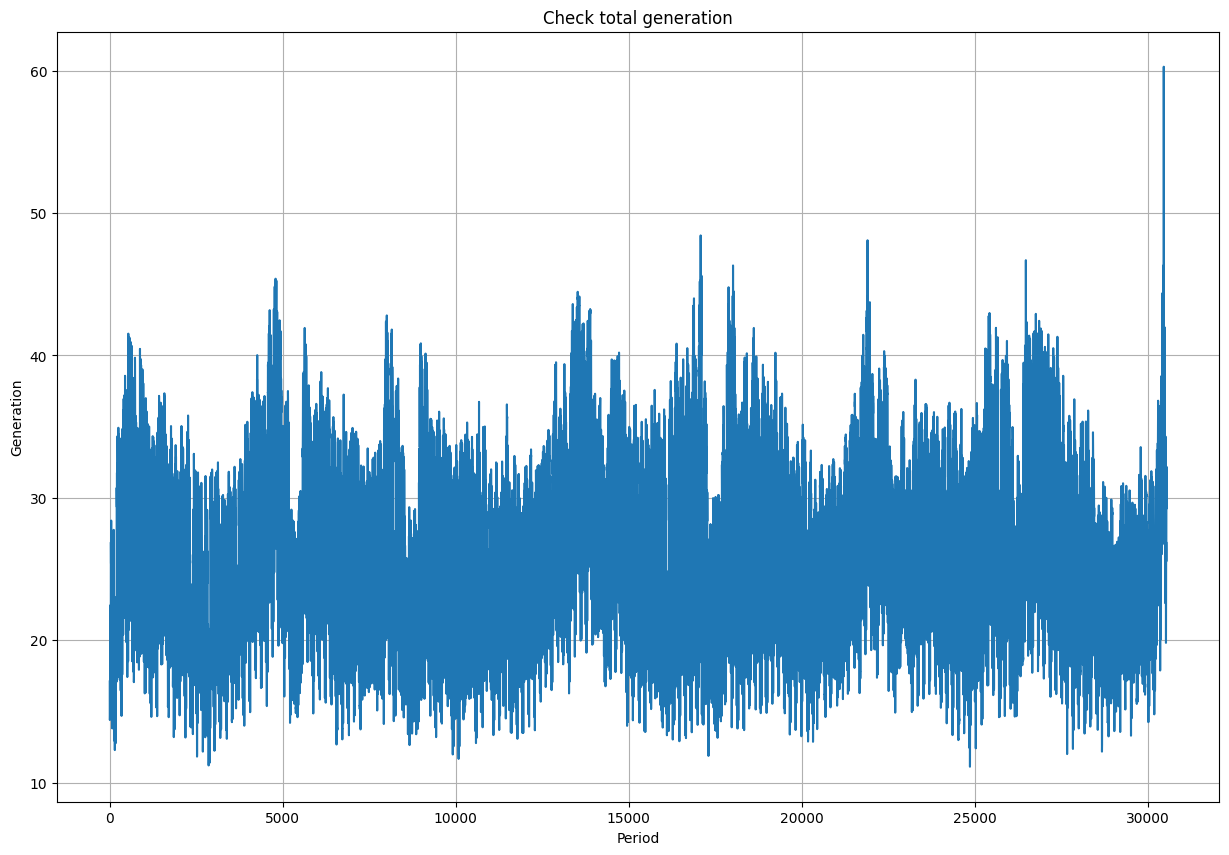

In [10]:
# Visual check

# import library
import matplotlib.pyplot as plt

# columns name
x = []
y = generation_pivot['TOT Generation']

for i in range(len(generation_pivot)):
    x.append(i+1)


fig, ax = plt.subplots(figsize=(15, 10), sharex=True)

# plot graph
ax.plot(x, y)

ax.set(xlabel='Period', ylabel='Generation',
       title='Check total generation')
ax.grid()

plt.show()